# การบ้านที่ 2 · Data Profiling ข้อมูลลูกค้า `customers.csv`

ต่อยอดจาก Lab 2.1: ครั้งนี้เราจะตรวจ **ข้อมูลสมาชิก** ของร้านบ้านบรู 3,000 คน เพื่อหาความผิดปกติก่อนนำไปแสดงบน Dashboard

**Prompt ที่ใช้**
```
ช่วยทำ data profiling หรือค้นหาความผิดปกติของข้อมูล customers.csv
แล้วสร้างเป็นไฟล์สำหรับทำงานบน google colab ดังตัวอย่าง Lab2_1_Data_Cleaning_NK.ipynb
```

| ขั้น | ทำอะไร |
|---|---|
| 0 | เตรียมเครื่องมือและโหลดไฟล์ |
| 1 | ดูข้อมูลครั้งแรก |
| 2 | Profiling ภายในตาราง: รูปแบบ ค่าว่าง ค่าซ้ำ ค่าที่อนุญาต |
| 3 | Profiling ข้ามตาราง: เทียบกับ `sales_clean.csv` และข้อมูลสาขา |
| 4 | สรุปปัญหาและตัดสินใจ |
| 5 | ทำความสะอาดและเตรียมข้อมูลสำหรับ Dashboard |
| 6 | Verify, ดูภาพรวม และ export |

**ไฟล์ที่ต้องอัปโหลด:** `customers.csv` และ `sales_clean.csv` (ผลลัพธ์จาก Lab 2.1)

## ขั้นที่ 0 · เตรียมเครื่องมือ
เหมือน Lab 2.1: อ่าน **ทุกคอลัมน์เป็นข้อความ** และ `keep_default_na=False` เพื่อไม่ให้ pandas ซ่อนปัญหา (เช่นค่าว่างกลายเป็น NaN หรือ `C00001` ถูกเดาเป็นตัวเลข)

In [1]:
import os, re
import pandas as pd

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

# ค่ามาตรฐานจาก README ของชุดข้อมูล และ branches.csv
VALID_GENDER = ["หญิง", "ชาย", "ไม่ระบุ"]
AGE_ORDER = ["ต่ำกว่า 18", "18-24", "25-34", "35-44", "45-54", "55+"]
BRANCHES = pd.DataFrame({
    "branch_id":   ["B01", "B02", "B03", "B04", "B05"],
    "branch":      ["สยาม", "สีลม", "อารีย์", "บางนา", "มหาวิทยาลัย"],
    "opened_date": ["2023-06-01", "2023-09-15", "2025-11-01", "2024-03-01", "2024-06-01"],
})
DATA_START, DATA_END = "2025-04-01", "2026-09-20"   # ช่วงเวลาของข้อมูลยอดขาย


def load_csv(name):
    """อ่าน CSV ทุกคอลัมน์เป็นข้อความ ถ้าไม่มีไฟล์จะให้อัปโหลด (Google Colab)"""
    if not os.path.exists(name):
        try:
            from google.colab import files
            print(f"ไม่พบ {name} กรุณาอัปโหลดไฟล์")
            files.upload()
        except ImportError:
            raise FileNotFoundError(f"ไม่พบไฟล์ {name} ให้วางไฟล์ไว้โฟลเดอร์เดียวกับ notebook")
    return pd.read_csv(name, dtype=str, keep_default_na=False)


issues = []   # เก็บผล profiling ทุกข้อ ไว้สรุปเป็นตารางในขั้นที่ 4
def report(check, n, detail=""):
    issues.append({"การตรวจ": check, "จำนวนแถว": int(n), "รายละเอียด": detail})
    print(("✅ " if n == 0 else "⚠️ ") + f"{check}: {int(n):,}" + (f" · {detail}" if detail else ""))

## ขั้นที่ 1 · ดูข้อมูลครั้งแรก

In [2]:
cust = load_csv("customers.csv")
sales = load_csv("sales_clean.csv")
print(f"customers: {len(cust):,} แถว × {cust.shape[1]} คอลัมน์")
print(f"sales_clean: {len(sales):,} แถว")
cust.head(8)

customers: 3,000 แถว × 7 คอลัมน์
sales_clean: 53,057 แถว


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
0,C00001,กมล,หญิง,18-24,B02,2026-03-03,082-xxx-6693
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18,084-xxx-3734
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04,089-xxx-9286
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05,083-xxx-7314
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10,083-xxx-5701
5,C00006,กมล,ชาย,18-24,B04,2026-08-16,086-xxx-1895
6,C00007,วรรณ,ชาย,45-54,B03,2026-07-17,087-xxx-3147
7,C00008,ภัทร,หญิง,25-34,B01,2026-04-07,087-xxx-9877


## ขั้นที่ 2 · Profiling ภายในตาราง (รายงานอย่างเดียว ยังไม่แก้)

### 2.1 ภาพรวมรายคอลัมน์

In [3]:
overview = pd.DataFrame({
    "ค่าว่าง": (cust.apply(lambda s: s.str.strip()) == "").sum(),
    "มีช่องว่างหัว/ท้าย": (cust != cust.apply(lambda s: s.str.strip())).sum(),
    "ค่าไม่ซ้ำ": cust.nunique(),
    "ตัวอย่าง": cust.iloc[0],
})
overview

,ค่าว่าง,มีช่องว่างหัว/ท้าย,ค่าไม่ซ้ำ,ตัวอย่าง
customer_id,0,0,3000,C00001
nickname,0,0,24,กมล
gender,0,0,3,หญิง
age_group,0,0,6,18-24
home_branch_id,0,0,5,B02
joined_date,0,0,530,2026-03-03
phone,0,0,2950,082-xxx-6693


### 2.2 ความครบถ้วนและค่าซ้ำ

In [4]:
report("ค่าว่าง (ทุกคอลัมน์รวมกัน)", (cust.apply(lambda s: s.str.strip()) == "").sum().sum())
report("แถวซ้ำทุกคอลัมน์", cust.duplicated().sum())
report("customer_id ซ้ำ", cust["customer_id"].duplicated().sum())
report("customer_id ผิดรูปแบบ (ไม่ใช่ C + ตัวเลข 5 หลัก)", (~cust["customer_id"].str.match(r"^C\d{5}$")).sum())

✅ ค่าว่าง (ทุกคอลัมน์รวมกัน): 0
✅ แถวซ้ำทุกคอลัมน์: 0
✅ customer_id ซ้ำ: 0
✅ customer_id ผิดรูปแบบ (ไม่ใช่ C + ตัวเลข 5 หลัก): 0


### 2.3 ค่าในคอลัมน์หมวดหมู่ต้องอยู่ในรายการที่อนุญาต

In [5]:
for col, valid in [("gender", VALID_GENDER), ("age_group", AGE_ORDER), ("home_branch_id", BRANCHES["branch_id"].tolist())]:
    print(f"\n— {col} —")
    print(cust[col].map(repr).value_counts().to_string())
    report(f"{col} ไม่อยู่ในรายการมาตรฐาน", (~cust[col].isin(valid)).sum())


— gender —
gender
'หญิง'       1652
'ชาย'        1232
'ไม่ระบุ'     116
✅ gender ไม่อยู่ในรายการมาตรฐาน: 0

— age_group —
age_group
'25-34'         993
'18-24'         775
'35-44'         577
'45-54'         346
'55+'           196
'ต่ำกว่า 18'    113
✅ age_group ไม่อยู่ในรายการมาตรฐาน: 0

— home_branch_id —
home_branch_id
'B01'    776
'B05'    693
'B02'    643
'B04'    483
'B03'    405
✅ home_branch_id ไม่อยู่ในรายการมาตรฐาน: 0


### 2.4 วันที่สมัคร `joined_date`

In [6]:
jd = cust["joined_date"]
report("joined_date ไม่ใช่รูปแบบ YYYY-MM-DD", (~jd.str.match(r"^\d{4}-\d\d-\d\d$")).sum())
report("joined_date แปลงเป็นวันที่ไม่ได้", pd.to_datetime(jd, format="%Y-%m-%d", errors="coerce").isna().sum())
report("joined_date เป็นปี พ.ศ.", jd.str.match(r"^25\d\d-").sum())
report("joined_date อยู่นอกช่วงข้อมูล", ((jd < DATA_START) | (jd > DATA_END)).sum(), f"ช่วงข้อมูล {DATA_START} ถึง {DATA_END}")

m = cust.merge(BRANCHES, left_on="home_branch_id", right_on="branch_id", how="left")
report("สมัครก่อนสาขาประจำเปิด", (m["joined_date"] < m["opened_date"]).sum(), "เช่น สมัครที่อารีย์ก่อน 1 พ.ย. 68")

print(f"\nช่วง joined_date: {jd.min()} ถึง {jd.max()}")
print("จำนวนสมัครต่อเดือน (เดือนสุดท้ายมีข้อมูลไม่ครบเดือน):")
print(jd.str[:7].value_counts().sort_index().to_string())

✅ joined_date ไม่ใช่รูปแบบ YYYY-MM-DD: 0
✅ joined_date แปลงเป็นวันที่ไม่ได้: 0
✅ joined_date เป็นปี พ.ศ.: 0
✅ joined_date อยู่นอกช่วงข้อมูล: 0 · ช่วงข้อมูล 2025-04-01 ถึง 2026-09-20
✅ สมัครก่อนสาขาประจำเปิด: 0 · เช่น สมัครที่อารีย์ก่อน 1 พ.ย. 68

ช่วง joined_date: 2025-04-01 ถึง 2026-09-14
จำนวนสมัครต่อเดือน (เดือนสุดท้ายมีข้อมูลไม่ครบเดือน):
joined_date
2025-04    138
2025-05    140
2025-06    142
2025-07    142
2025-08    144
2025-09    148
2025-10    145
2025-11    175
2025-12    197
2026-01    190
2026-02    161
2026-03    189
2026-04    201
2026-05    200
2026-06    182
2026-07    210
2026-08    215
2026-09     81


### 2.5 เบอร์โทร `phone` (ข้อมูลส่วนบุคคล · PDPA)
เบอร์ถูกปิดบังบางส่วนเป็น `08X-xxx-1234` แล้ว เหลือเลขจริงแค่ 5 หลัก

In [7]:
pattern = cust["phone"].str.replace(r"\d", "9", regex=True)
print(pattern.value_counts().to_string())
report("phone ไม่ใช่รูปแบบ 0XX-xxx-XXXX", (~cust["phone"].str.match(r"^0\d{2}-xxx-\d{4}$")).sum())

dup_phone = cust[cust["phone"].duplicated(keep=False)].sort_values("phone")
report("phone ที่ปิดบังแล้วซ้ำกัน", len(dup_phone), f"{dup_phone['phone'].nunique()} เบอร์ ใช้ร่วมกัน")
same_person = dup_phone.duplicated(["phone", "nickname", "gender", "age_group"], keep=False).sum()
print(f"ในกลุ่มเบอร์ซ้ำ มีกี่แถวที่ชื่อ เพศ และช่วงอายุเหมือนกันด้วย (น่าจะเป็นคนเดียวกัน): {same_person}")
dup_phone.head(6)

phone
999-xxx-9999    3000
✅ phone ไม่ใช่รูปแบบ 0XX-xxx-XXXX: 0
⚠️ phone ที่ปิดบังแล้วซ้ำกัน: 99 · 49 เบอร์ ใช้ร่วมกัน
ในกลุ่มเบอร์ซ้ำ มีกี่แถวที่ชื่อ เพศ และช่วงอายุเหมือนกันด้วย (น่าจะเป็นคนเดียวกัน): 0


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
2206,C02207,ทิพย์,ชาย,35-44,B02,2025-04-14,081-xxx-4308
2247,C02248,อัญชลี,ชาย,35-44,B02,2026-03-15,081-xxx-4308
2178,C02179,อัญชลี,หญิง,25-34,B01,2025-06-24,081-xxx-5843
2842,C02843,ธีร,หญิง,25-34,B05,2026-05-20,081-xxx-5843
1906,C01907,ศิริ,หญิง,25-34,B03,2026-03-31,081-xxx-6451
883,C00884,ภัทร,ชาย,45-54,B01,2025-09-07,081-xxx-6451


### 2.6 ความสอดคล้องระหว่างคอลัมน์
- **ชื่อเล่นกับเพศ:** ชื่อที่มักเป็นชื่อผู้ชาย/ผู้หญิงชัดเจน แต่เพศที่ระบุตรงข้าม
- **ลูกค้าอายุต่ำกว่า 18:** ตาม PDPA การเก็บข้อมูลผู้เยาว์ต้องได้รับความยินยอมจากผู้ปกครอง

In [8]:
MALE_NAMES = ["สมชาย", "มานพ", "วีระ", "กิตติ", "ภูมิ"]
FEMALE_NAMES = ["สุดา", "รัตนา", "อัญชลี", "พิม", "เกศ", "ปวีณ", "จิรา", "ทิพย์"]
mismatch = ((cust["nickname"].isin(MALE_NAMES) & (cust["gender"] == "หญิง")) |
            (cust["nickname"].isin(FEMALE_NAMES) & (cust["gender"] == "ชาย")))
report("ชื่อเล่นไม่สอดคล้องกับเพศ", mismatch.sum(), "เช่น 'สมชาย' ระบุเป็นหญิง")
print(pd.crosstab(cust.loc[mismatch, "nickname"], cust.loc[mismatch, "gender"]).to_string())

report("ลูกค้าอายุต่ำกว่า 18", (cust["age_group"] == "ต่ำกว่า 18").sum(), "ต้องมีความยินยอมจากผู้ปกครองตาม PDPA")
report("ไม่ระบุเพศ", (cust["gender"] == "ไม่ระบุ").sum(), "เป็นตัวเลือกที่ถูกต้อง ไม่ใช่ข้อมูลหาย")
print(f"\nชื่อเล่นมีแค่ {cust['nickname'].nunique()} ชื่อ สำหรับ {len(cust):,} คน จึงใช้ระบุตัวบุคคลไม่ได้")

⚠️ ชื่อเล่นไม่สอดคล้องกับเพศ: 707 · เช่น 'สมชาย' ระบุเป็นหญิง
gender    ชาย  หญิง
nickname           
กิตติ       0    71
จิรา       57     0
ทิพย์      50     0
ปวีณ       46     0
พิม        39     0
ภูมิ        0    67
มานพ        0    64
รัตนา      57     0
วีระ        0    53
สมชาย       0    59
สุดา       39     0
อัญชลี     62     0
เกศ        43     0
⚠️ ลูกค้าอายุต่ำกว่า 18: 113 · ต้องมีความยินยอมจากผู้ปกครองตาม PDPA
⚠️ ไม่ระบุเพศ: 116 · เป็นตัวเลือกที่ถูกต้อง ไม่ใช่ข้อมูลหาย

ชื่อเล่นมีแค่ 24 ชื่อ สำหรับ 3,000 คน จึงใช้ระบุตัวบุคคลไม่ได้


## ขั้นที่ 3 · Profiling ข้ามตาราง: เทียบกับยอดขาย
ข้อมูลที่ดูถูกต้องเมื่อดูตารางเดียว อาจขัดแย้งกันเมื่อนำมาเทียบกับตารางอื่น

In [9]:
s = sales[sales["customer_id"] != ""].copy()
s["date"] = s["datetime"].str[:10]
s["revenue"] = pd.to_numeric(s["qty"]) * pd.to_numeric(s["unit_price"])
s = s.merge(BRANCHES[["branch", "branch_id"]], on="branch", how="left")

per_cust = s.groupby("customer_id").agg(
    orders=("order_id", "nunique"),
    revenue=("revenue", "sum"),
    first_purchase=("date", "min"),
    last_purchase=("date", "max"),
    top_branch_id=("branch_id", lambda v: v.value_counts().index[0]),
)

report("customer_id ในยอดขายที่ไม่มีในทะเบียนสมาชิก", len(set(per_cust.index) - set(cust["customer_id"])),
       "orphan: ขายให้สมาชิกที่ไม่มีตัวตน")
report("สมาชิกที่ไม่เคยซื้อเลย", (~cust["customer_id"].isin(per_cust.index)).sum(),
       f"คิดเป็น {(~cust['customer_id'].isin(per_cust.index)).mean():.1%} ของสมาชิก")

j = cust.set_index("customer_id").join(per_cust, how="inner")
report("ซื้อครั้งแรกก่อนวันที่สมัครสมาชิก", (j["first_purchase"] < j["joined_date"]).sum())
report("สาขาประจำไม่ตรงกับสาขาที่ซื้อบ่อยที่สุด", (j["home_branch_id"] != j["top_branch_id"]).sum(),
       f"จาก {len(j):,} คนที่เคยซื้อ")

lag = (pd.to_datetime(j["first_purchase"]) - pd.to_datetime(j["joined_date"])).dt.days
print(f"\nจำนวนวันจากวันสมัครถึงซื้อครั้งแรก: ค่ากลาง {lag.median():.0f} วัน · สูงสุด {lag.max():,} วัน")

✅ customer_id ในยอดขายที่ไม่มีในทะเบียนสมาชิก: 0 · orphan: ขายให้สมาชิกที่ไม่มีตัวตน
⚠️ สมาชิกที่ไม่เคยซื้อเลย: 493 · คิดเป็น 16.4% ของสมาชิก
✅ ซื้อครั้งแรกก่อนวันที่สมัครสมาชิก: 0
⚠️ สาขาประจำไม่ตรงกับสาขาที่ซื้อบ่อยที่สุด: 115 · จาก 2,507 คนที่เคยซื้อ

จำนวนวันจากวันสมัครถึงซื้อครั้งแรก: ค่ากลาง 17 วัน · สูงสุด 411 วัน


## ขั้นที่ 4 · สรุปผล Profiling

In [10]:
summary = pd.DataFrame(issues)
summary["สถานะ"] = summary["จำนวนแถว"].map(lambda n: "✅ ผ่าน" if n == 0 else "⚠️ พบ")
summary

,การตรวจ,จำนวนแถว,รายละเอียด,สถานะ
0,ค่าว่าง (ทุกคอลัมน์รวมกัน),0,,✅ ผ่าน
1,แถวซ้ำทุกคอลัมน์,0,,✅ ผ่าน
2,customer_id ซ้ำ,0,,✅ ผ่าน
3,customer_id ผิดรูปแบบ (ไม่ใช่ C + ตัวเลข 5 หลัก),0,,✅ ผ่าน
4,gender ไม่อยู่ในรายการมาตรฐาน,0,,✅ ผ่าน
5,age_group ไม่อยู่ในรายการมาตรฐาน,0,,✅ ผ่าน
6,home_branch_id ไม่อยู่ในรายการมาตรฐาน,0,,✅ ผ่าน
7,joined_date ไม่ใช่รูปแบบ YYYY-MM-DD,0,,✅ ผ่าน
8,joined_date แปลงเป็นวันที่ไม่ได้,0,,✅ ผ่าน
9,joined_date เป็นปี พ.ศ.,0,,✅ ผ่าน


### ตัดสินใจก่อนลงมือ

ข้อมูลชุดนี้ **สะอาดในเชิงโครงสร้าง** แล้ว: ไม่มีค่าว่าง ไม่มีแถวซ้ำ รูปแบบถูกต้องทุกแถว แต่มี **ความผิดปกติเชิงธุรกิจและเรื่อง PDPA** ที่ต้องตัดสินใจ

| ปัญหาที่พบ | ทางเลือก | ตัดสินใจ | เหตุผล |
|---|---|---|---|
| phone ที่ปิดบังแล้วซ้ำกัน (99 แถว / 49 เบอร์) | ลบซ้ำ / เก็บ | **เก็บทุกแถว แต่ห้ามใช้ phone เป็น key** | ชื่อ เพศ อายุ สาขาต่างกันหมด จึงเป็นคนละคนกัน ที่ซ้ำเพราะปิดบังเลขไปแล้วเหลือแค่ 5 หลัก |
| phone เป็นข้อมูลส่วนบุคคล | เก็บ / ตัดออก | **ตัดออกจากไฟล์ที่ใช้บน Dashboard** | หลัก Data Minimization ของ PDPA: Dashboard เป็นเว็บที่คนอื่นเปิดดูได้ และไม่ได้ใช้เบอร์ |
| nickname | เก็บ / ตัดออก | **ตัดออกจากไฟล์ Dashboard** | กราฟไม่ได้ใช้ชื่อเล่น ใช้ customer_id เป็น key ได้อยู่แล้ว |
| ชื่อเล่นไม่สอดคล้องกับเพศ | แก้เพศตามชื่อ / เก็บ | **เก็บตามเดิม** | เพศเป็นข้อมูลที่ลูกค้าระบุเอง ไม่ควรเดาจากชื่อ ชื่อเล่นไทยหลายชื่อใช้ได้ทั้งสองเพศ ให้รายงานเป็นข้อสังเกตแทน |
| ลูกค้าอายุต่ำกว่า 18 (113 คน) | ลบ / เก็บพร้อม flag | **เก็บ และเพิ่มคอลัมน์ is_minor** | เป็นลูกค้าจริง แต่ต้องตรวจว่ามีความยินยอมจากผู้ปกครอง และห้ามใช้ทำการตลาดตรง |
| สมาชิกที่ไม่เคยซื้อ (493 คน) | ลบ / เก็บ | **เก็บ และเพิ่มคอลัมน์ has_purchase** | เป็นกลุ่มเป้าหมายสำคัญสำหรับแคมเปญกระตุ้นการซื้อครั้งแรก ถ้าลบทิ้งจะเข้าใจผิดว่าสมาชิกทุกคน active |
| สาขาประจำไม่ตรงกับสาขาที่ซื้อบ่อย (115 คน) | แก้ / เก็บ | **เก็บ home_branch_id ตามเดิม และเพิ่ม top_branch** | สาขาประจำคือสาขาที่สมัคร ไม่ใช่ข้อผิดพลาด แต่ควรดูทั้งสองค่า |
| เดือน ก.ย. 69 ข้อมูลไม่ครบเดือน | ตัด / เก็บพร้อมบอก | **เก็บ และระบุในกราฟ** | เป็นบทเรียนเดียวกับกราฟ 4 ใน Lab 2.2 |

## ขั้นที่ 5 · ทำความสะอาดและเตรียมข้อมูลสำหรับ Dashboard
ทำงานบน `clean = cust.copy()` ห้ามแก้ `cust` และเก็บ log ทุกขั้นตอน

In [11]:
clean = cust.copy()
log = []
def add_log(step, rows, decision):
    log.append({"ขั้นตอน": step, "จำนวนแถวที่กระทบ": int(rows), "การตัดสินใจ": decision})

# 1) ตัดช่องว่างหัวท้ายทุกคอลัมน์ (ป้องกันไว้ก่อน แม้ profiling จะไม่พบ)
before = clean.copy()
clean = clean.apply(lambda s: s.str.strip())
add_log("ตัดช่องว่างหัว/ท้าย", (before != clean).any(axis=1).sum(), "strip ทุกคอลัมน์")

# 2) PDPA: ตัดข้อมูลที่ระบุตัวบุคคลได้ออก เพราะ Dashboard ไม่ได้ใช้
clean = clean.drop(columns=["phone", "nickname"])
add_log("ตัด phone และ nickname", len(clean), "Data Minimization: Dashboard เป็นเว็บสาธารณะ")

# 3) เพิ่มชื่อสาขาประจำ (join กับข้อมูลสาขา)
clean = clean.merge(BRANCHES[["branch_id", "branch"]].rename(columns={"branch_id": "home_branch_id", "branch": "home_branch"}),
                    on="home_branch_id", how="left")
add_log("เพิ่ม home_branch (ชื่อสาขา)", clean["home_branch"].notna().sum(), "join กับ branches")

# 4) เพิ่มพฤติกรรมการซื้อจาก sales_clean
clean = clean.merge(per_cust.reset_index(), on="customer_id", how="left")
clean["has_purchase"] = clean["orders"].notna()
clean["orders"] = clean["orders"].fillna(0).astype(int)
clean["revenue"] = clean["revenue"].fillna(0).astype(int)
clean[["first_purchase", "last_purchase", "top_branch_id"]] = clean[["first_purchase", "last_purchase", "top_branch_id"]].fillna("")
add_log("เพิ่ม orders, revenue, first/last_purchase", clean["has_purchase"].sum(), "สรุปจาก sales_clean.csv")
add_log("flag has_purchase = False", (~clean["has_purchase"]).sum(), "เก็บไว้: สมาชิกที่ยังไม่เคยซื้อ")

# 5) flag ผู้เยาว์
clean["is_minor"] = clean["age_group"] == "ต่ำกว่า 18"
add_log("flag is_minor", clean["is_minor"].sum(), "เก็บไว้: ต้องตรวจความยินยอมผู้ปกครอง")

# 6) คอลัมน์ช่วยสำหรับกราฟ
clean["join_month"] = clean["joined_date"].str[:7]
clean["recency_days"] = (pd.Timestamp(DATA_END) - pd.to_datetime(clean["last_purchase"].replace("", None))).dt.days
clean["recency_days"] = clean["recency_days"].astype("Int64")

clean = clean[["customer_id", "gender", "age_group", "home_branch_id", "home_branch", "joined_date", "join_month",
               "is_minor", "has_purchase", "orders", "revenue", "first_purchase", "last_purchase", "recency_days", "top_branch_id"]]
cleaning_log = pd.DataFrame(log)
display(cleaning_log)
print(f"จำนวนแถว: ก่อน {len(cust):,} → หลัง {len(clean):,} (ไม่ได้ลบลูกค้าคนไหน)")
clean.head()

,ขั้นตอน,จำนวนแถวที่กระทบ,การตัดสินใจ
0,ตัดช่องว่างหัว/ท้าย,0,strip ทุกคอลัมน์
1,ตัด phone และ nickname,3000,Data Minimization: Dashboard เป็นเว็บสาธารณะ
2,เพิ่ม home_branch (ชื่อสาขา),3000,join กับ branches
3,"เพิ่ม orders, revenue, first/last_purchase",2507,สรุปจาก sales_clean.csv
4,flag has_purchase = False,493,เก็บไว้: สมาชิกที่ยังไม่เคยซื้อ
5,flag is_minor,113,เก็บไว้: ต้องตรวจความยินยอมผู้ปกครอง


จำนวนแถว: ก่อน 3,000 → หลัง 3,000 (ไม่ได้ลบลูกค้าคนไหน)


,customer_id,gender,age_group,home_branch_id,home_branch,joined_date,join_month,is_minor,has_purchase,orders,revenue,first_purchase,last_purchase,recency_days,top_branch_id
0,C00001,หญิง,18-24,B02,สีลม,2026-03-03,2026-03,False,True,3,344,2026-03-19,2026-04-30,143,B02
1,C00002,ชาย,25-34,B04,บางนา,2026-01-18,2026-01,False,True,5,504,2026-02-17,2026-05-30,113,B04
2,C00003,หญิง,18-24,B04,บางนา,2025-05-04,2025-05,False,True,11,1178,2025-05-04,2025-08-25,391,B04
3,C00004,หญิง,18-24,B05,มหาวิทยาลัย,2026-05-05,2026-05,False,False,0,0,,,<NA>,
4,C00005,หญิง,25-34,B04,บางนา,2026-07-10,2026-07,False,True,3,800,2026-07-31,2026-08-09,42,B04


## ขั้นที่ 6 · Verify

In [12]:
def validate(c):
    ok = True
    def rep(passed, msg):
        nonlocal ok
        ok &= bool(passed)
        print(("✅ " if passed else "❌ ") + msg)
    rep(len(c) == len(cust), f"จำนวนลูกค้าเท่าเดิม ({len(c):,} คน)")
    rep(c["customer_id"].is_unique, "customer_id ไม่ซ้ำ")
    rep(not {"phone", "nickname"} & set(c.columns), "ไม่มีข้อมูลส่วนบุคคล (phone, nickname)")
    rep(c["gender"].isin(VALID_GENDER).all() and c["age_group"].isin(AGE_ORDER).all(), "gender และ age_group เป็นค่ามาตรฐาน")
    rep(c["home_branch"].notna().all(), "ทุกคนมีชื่อสาขาประจำ")
    rep(c["revenue"].sum() == int(s["revenue"].sum()), f"ยอดซื้อรวมของสมาชิกตรงกับ sales (฿{c['revenue'].sum():,})")
    rep(c["orders"].sum() == s["order_id"].nunique(), f"จำนวนบิลของสมาชิกตรงกับ sales ({c['orders'].sum():,} บิล)")
    rep(((c["first_purchase"] == "") | (c["first_purchase"] >= c["joined_date"])).all(), "ไม่มีการซื้อก่อนวันสมัคร")
    print("\n🎉 พร้อม export" if ok else "\nยังมีจุดต้องแก้")
    return ok

validate(clean)

✅ จำนวนลูกค้าเท่าเดิม (3,000 คน)
✅ customer_id ไม่ซ้ำ
✅ ไม่มีข้อมูลส่วนบุคคล (phone, nickname)
✅ gender และ age_group เป็นค่ามาตรฐาน
✅ ทุกคนมีชื่อสาขาประจำ
✅ ยอดซื้อรวมของสมาชิกตรงกับ sales (฿2,073,443)
✅ จำนวนบิลของสมาชิกตรงกับ sales (16,022 บิล)
✅ ไม่มีการซื้อก่อนวันสมัคร

🎉 พร้อม export


True

### ภาพรวมลูกค้า (ใช้ป้ายภาษาอังกฤษ เพราะ matplotlib ใน Colab ไม่มีฟอนต์ไทย)

Matplotlib is building the font cache; this may take a moment.


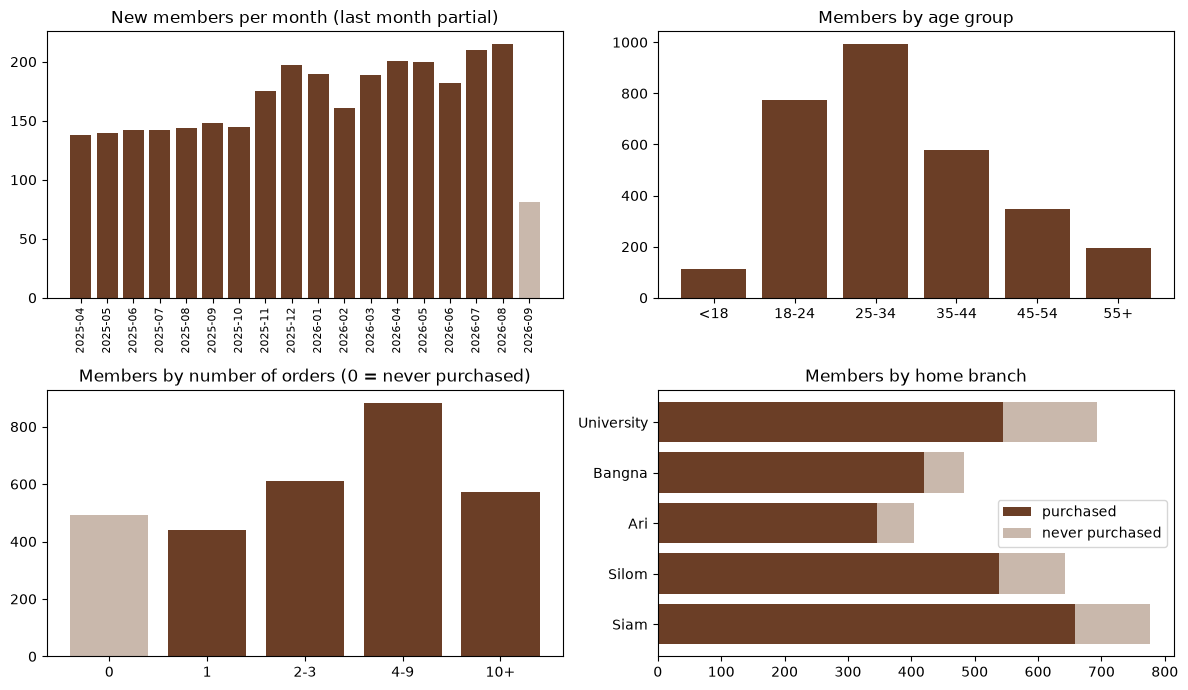

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
COLOR = "#6B3E26"

# 1) สมาชิกใหม่ต่อเดือน (เดือนสุดท้ายไม่ครบเดือน → สีจาง)
jm = clean["join_month"].value_counts().sort_index()
colors = [COLOR] * (len(jm) - 1) + ["#C9B8AC"]
axes[0, 0].bar(jm.index, jm.values, color=colors)
axes[0, 0].set_title("New members per month (last month partial)")
axes[0, 0].tick_params(axis="x", rotation=90, labelsize=8)

# 2) ช่วงอายุ
age_en = {"ต่ำกว่า 18": "<18"}
ag = clean["age_group"].value_counts().reindex(AGE_ORDER)
axes[0, 1].bar([age_en.get(a, a) for a in ag.index], ag.values, color=COLOR)
axes[0, 1].set_title("Members by age group")

# 3) จำนวนครั้งที่ซื้อ
bins = pd.cut(clean["orders"], [-1, 0, 1, 3, 9, 1000], labels=["0", "1", "2-3", "4-9", "10+"])
fq = bins.value_counts().sort_index()
axes[1, 0].bar(fq.index.astype(str), fq.values, color=[ "#C9B8AC"] + [COLOR] * 4)
axes[1, 0].set_title("Members by number of orders (0 = never purchased)")

# 4) สมาชิกต่อสาขา: active vs ไม่เคยซื้อ
br_en = {"B01": "Siam", "B02": "Silom", "B03": "Ari", "B04": "Bangna", "B05": "University"}
bb = clean.groupby(["home_branch_id", "has_purchase"]).size().unstack(fill_value=0)
axes[1, 1].barh([br_en[b] for b in bb.index], bb[True], color=COLOR, label="purchased")
axes[1, 1].barh([br_en[b] for b in bb.index], bb[False], left=bb[True], color="#C9B8AC", label="never purchased")
axes[1, 1].set_title("Members by home branch"); axes[1, 1].legend()

plt.tight_layout(); plt.show()

## ขั้นที่ 7 · Export

In [14]:
clean.to_csv("customers_clean.csv", index=False, encoding="utf-8-sig")
cleaning_log.to_csv("customers_cleaning_log.csv", index=False, encoding="utf-8-sig")
summary.to_csv("customers_profiling_report.csv", index=False, encoding="utf-8-sig")
print("บันทึก customers_clean.csv, customers_cleaning_log.csv และ customers_profiling_report.csv แล้ว")

try:
    from google.colab import files
    for f in ["customers_clean.csv", "customers_cleaning_log.csv", "customers_profiling_report.csv"]:
        files.download(f)
except ImportError:
    pass

บันทึก customers_clean.csv, customers_cleaning_log.csv และ customers_profiling_report.csv แล้ว


## สรุปผล Profiling

1. **โครงสร้างข้อมูลสะอาด:** 3,000 แถว ไม่มีค่าว่าง ไม่มีแถวซ้ำ `customer_id` ไม่ซ้ำ ค่าหมวดหมู่และรูปแบบวันที่ถูกต้องทุกแถว ต่างจาก `sales_raw.csv` ที่ต้องแก้หลายจุด
2. **เบอร์โทรใช้เป็น key ไม่ได้:** หลังปิดบังเบอร์แล้วมี 49 เบอร์ที่ซ้ำกัน (99 แถว) แต่เป็นคนละคนกัน
3. **สมาชิก 16.4% (493 คน) ไม่เคยซื้อเลย:** เป็นโอกาสทางการตลาด เช่น ส่งคูปองซื้อครั้งแรก
4. **ความเสี่ยงด้าน PDPA:** มีผู้เยาว์ 113 คน และมีเบอร์โทรในไฟล์ จึงตัด phone และ nickname ออกก่อนนำขึ้นเว็บ และ flag ผู้เยาว์ไว้
5. **ข้อสังเกตที่ไม่ได้แก้:** มีกรณีชื่อเล่นไม่สอดคล้องกับเพศ และสาขาประจำไม่ตรงกับสาขาที่ซื้อบ่อยที่สุด ทั้งสองเรื่องไม่ใช่ข้อมูลผิด จึงไม่ควรแก้ด้วยการเดา

**นำไปใช้ต่อ:** คัดลอก `customers_clean.csv` ไปวางใน `public/` ของ Baanbrew-dashboard เพื่อแสดงในแท็บ "ลูกค้า"